# Supplementary Figure S1 — Runtime comparison of PARSE and DSSR

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
# make scripts/paths.py importable regardless of where the kernel starts


plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})
DSSR_COLOR  = "#C0392B"   # red
PARSE_COLOR = "#2C7FB8"   # blue

In [3]:
df = pd.read_csv(data_file("benchmark/dssr_PARSE_time_benchmark.csv"))
df = df[(df["Nucleotides"] > 0) & (df["dssr_avg"] > 0) & (df["parse_avg"] > 0)].copy()
print(f"{len(df)} structures  |  {df.Nucleotides.min()}-{df.Nucleotides.max()} nt")

def trend(n, t, deg=2):
    return np.polyfit(np.log10(n), np.log10(t), deg)
coef_d = trend(df.Nucleotides, df.dssr_avg)
coef_p = trend(df.Nucleotides, df.parse_avg)

2096 structures  |  4-15870 nt


saved figures/figS1_runtime_comparison.png


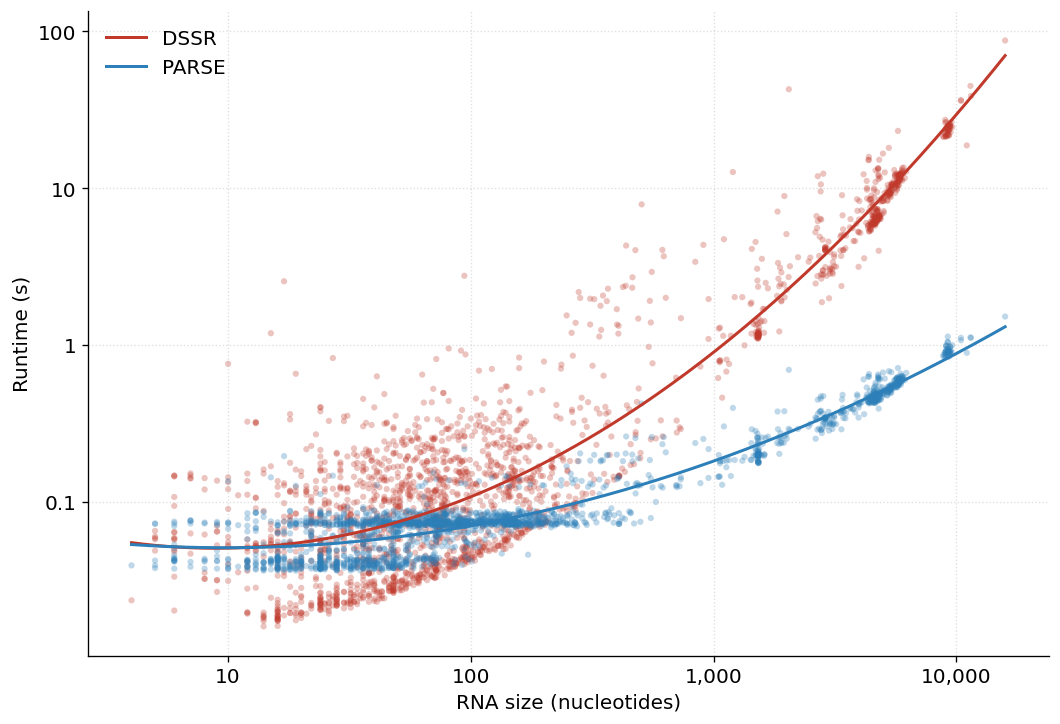

In [4]:
fig, ax = plt.subplots(figsize=(9, 6.2))
ax.scatter(df.Nucleotides, df.dssr_avg,  s=14, alpha=0.30, color=DSSR_COLOR,  edgecolors="none")
ax.scatter(df.Nucleotides, df.parse_avg, s=14, alpha=0.30, color=PARSE_COLOR, edgecolors="none")
xs = np.logspace(np.log10(df.Nucleotides.min()), np.log10(df.Nucleotides.max()), 300)
ax.plot(xs, 10 ** np.polyval(coef_d, np.log10(xs)), color=DSSR_COLOR,  lw=1.8, label="DSSR")
ax.plot(xs, 10 ** np.polyval(coef_p, np.log10(xs)), color=PARSE_COLOR, lw=1.8, label="PARSE")
ax.set_xscale("log"); ax.set_yscale("log")
ax.xaxis.set_major_locator(FixedLocator([10, 100, 1000, 10000]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_locator(FixedLocator([0.01, 0.1, 1, 10, 100]))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
ax.grid(which="major", ls=":", alpha=0.4)
ax.set_xlabel("RNA size (nucleotides)")
ax.set_ylabel("Runtime (s)")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
out = savefig(fig, "figS1_runtime_comparison.png")
print("saved", out)
plt.show()

## Runtime comparison of PARSE and DSSR

Runtime vs RNA size (log–log); PARSE scales better than DSSR.